In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [189]:
import scipy.stats as stats
from scipy.stats import beta as beta_dist
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.multitest import multipletests

In [190]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = {"control": "#4C72B0", "treatment": "#DD8452", "neutral": "#55A868"}
seed = 42
np.random.seed(seed)

In [191]:
df_ab = pd.read_csv("ab_test.csv")
df_countries = pd.read_csv("countries_ab.csv")

In [192]:
df_ab.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [193]:
df_countries.head()

,id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [194]:
df_ab['id'].isin(df_countries['id']).sum()

np.int64(294478)

In [195]:
df = pd.merge(df_ab, df_countries, on='id')
df.head()

,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [196]:
def info_data(df):
    print("Shape of the dataset:", df.shape)
    print("\nData types:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nUnique values:\n", df.nunique())

In [197]:
info_data(df)

Shape of the dataset: (294478, 6)

Data types:
 id            int64
time         object
con_treat    object
page         object
converted     int64
country      object
dtype: object

Missing values:
 id           0
time         0
con_treat    0
page         0
converted    0
country      0
dtype: int64

Unique values:
 id           290584
time          35993
con_treat         2
page              2
converted         2
country           3
dtype: int64


In [198]:
df['time'] = pd.to_timedelta('00:' + df['time'].astype(str))

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype          
---  ------     --------------   -----          
 0   id         294478 non-null  int64          
 1   time       294478 non-null  timedelta64[ns]
 2   con_treat  294478 non-null  object         
 3   page       294478 non-null  object         
 4   converted  294478 non-null  int64          
 5   country    294478 non-null  object         
dtypes: int64(2), object(3), timedelta64[ns](1)
memory usage: 13.5+ MB


In [200]:
print(df.groupby('id')[['page', 'converted']].sum().value_counts())

page              converted
new_page          0            126372
old_page          0            126073
                  1             17220
new_page          1             17025
new_pageold_page  0               760
old_pagenew_page  0               747
old_pageold_page  0               740
new_pagenew_page  0               719
old_pagenew_page  1               230
old_pageold_page  1               221
new_pageold_page  1               220
new_pagenew_page  1               193
new_pageold_page  2                21
old_pagenew_page  2                20
old_pageold_page  2                13
new_pagenew_page  2                10
Name: count, dtype: int64


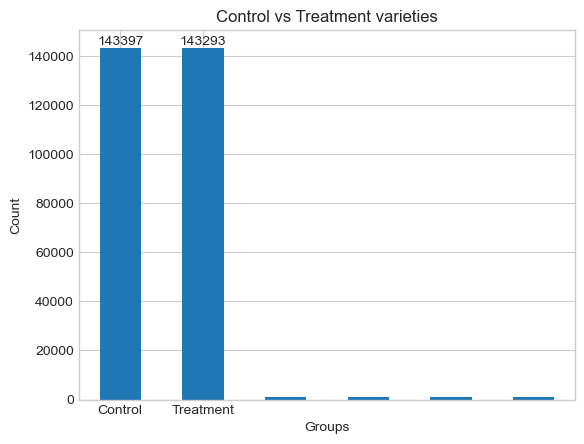

con_treat
treatment             143397
control               143293
controlcontrol          1007
treatmenttreatment       992
treatmentcontrol         963
controltreatment         932
Name: count, dtype: int64


In [201]:
df.groupby('id')['con_treat'].sum().value_counts().plot(kind = 'bar',title='Control vs Treatment varieties',xlabel='Groups', ylabel='Count')
plt.annotate(f"{df.groupby('id')['con_treat'].sum().value_counts()[0]}", xy=(0, df.groupby('id')['con_treat'].sum().value_counts()[0]), ha='center', va='bottom')
plt.annotate(f"{df.groupby('id')['con_treat'].sum().value_counts()[1]}", xy=(1, df.groupby('id')['con_treat'].sum().value_counts()[1]), ha='center', va='bottom')
plt.xticks(ticks=[0, 1], labels=['Control', 'Treatment'],rotation=0)
plt.show()
print(df.groupby('id')['con_treat'].sum().value_counts())

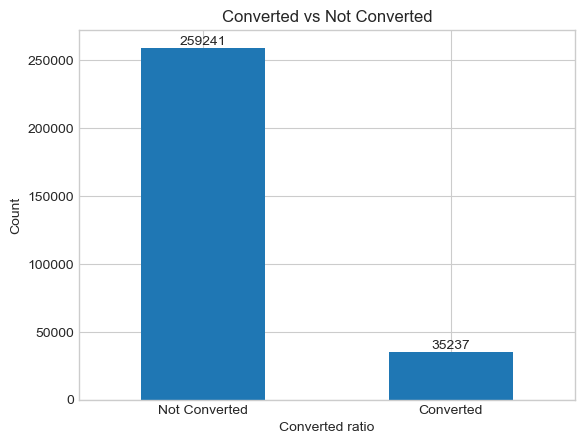

Not Converted: 88.03%
Converted: 11.97%


In [202]:
df['converted'].value_counts().plot(kind='bar', title='Converted vs Not Converted', xlabel='Converted ratio', ylabel='Count')
plt.xticks(ticks=[0, 1], labels=['Not Converted', 'Converted'],rotation=0)
plt.annotate(f"{df['converted'].value_counts()[0]}", xy=(0, df['converted'].value_counts()[0]), ha='center', va='bottom')
plt.annotate(f"{df['converted'].value_counts()[1]}", xy=(1, df['converted'].value_counts()[1]), ha='center', va='bottom')
plt.show()
print(f"Not Converted: {df['converted'].value_counts()[0]/df['converted'].count():.2%}")
print(f"Converted: {df['converted'].value_counts()[1]/df['converted'].count():.2%}")

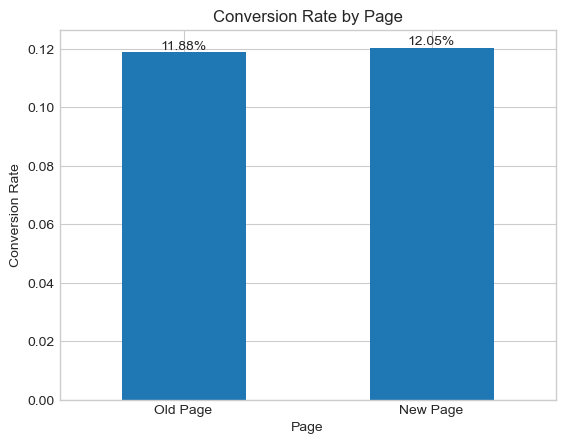

In [203]:
df.groupby('page')['converted'].mean().plot(kind='bar', title='Conversion Rate by Page', xlabel='Page', ylabel='Conversion Rate')
plt.xticks(ticks=[0, 1], labels=['Old Page', 'New Page'],rotation=0)
plt.annotate(f"{df.groupby('page')['converted'].mean()[0]:.2%}", xy=(0, df.groupby('page')['converted'].mean()[0]), ha='center', va='bottom')
plt.annotate(f"{df.groupby('page')['converted'].mean()[1]:.2%}", xy=(1, df.groupby('page')['converted'].mean()[1]), ha='center', va='bottom')
plt.show()

### Data Quality Audit

In [204]:
def load_and_validate(df: pd.DataFrame) -> pd.DataFrame:
    """Audit integrity by cleaning messy labels and checking for contamination."""
    print("=" * 60 + "\nDATA QUALITY AUDIT\n" + "=" * 60)
    
    con_treat_conditions = [
        (df['con_treat'].isin(['control', 'controlcontrol'])),
        (df['con_treat'].isin(['treatment', 'treatmenttreatment']))
    ]
    df['group_clean'] = np.select(con_treat_conditions, ['control', 'treatment'], default='neither')

    page_conditions = [
        (df['page'].isin(['old_page', 'old_pageold_page'])),
        (df['page'].isin(['new_page', 'new_pageview_page', 'new_pagenew_page']))
    ]
    df['page_clean'] = np.select(page_conditions, ['old_page', 'new_page'], default='other')
    
    
    multi_group = df.groupby("id")["group_clean"].nunique()
    contaminated_ids = multi_group[multi_group > 1].index
    
    if len(contaminated_ids) > 0:
        print(f"⚠ Users in multiple groups: {len(contaminated_ids)}. Removing...")
        df = df[~df["id"].isin(contaminated_ids)].copy()

    analysis_df = df[df['group_clean'].isin(['control', 'treatment'])]
    group_counts = analysis_df["group_clean"].value_counts()
    
    if len(group_counts) == 2:
        _, srm_pval = stats.chisquare(group_counts.values)
        srm_flag = "⚠ SRM DETECTED" if srm_pval < 0.05 else "✓ No SRM"
        print(f"SRM p-value: {srm_pval:.4f}  {srm_flag}")
    
    print(f"\nFinal Group Distribution:\n{df['group_clean'].value_counts()}")
    
    return df

df_validated = load_and_validate(df)

DATA QUALITY AUDIT
⚠ Users in multiple groups: 1895. Removing...
SRM p-value: 0.8908  ✓ No SRM

Final Group Distribution:
group_clean
treatment    145381
control      145307
Name: count, dtype: int64


In [214]:
def experiment_design_doc(baseline=0.12, mde=0.02, alpha=0.05, power=0.8):
    print("\n" + "=" * 60 + "\nEXPERIMENT DESIGN\n" + "=" * 60)
    # Effect size using arcsin transformation
    effect_size = 2 * (np.arcsin(np.sqrt(baseline + mde)) - np.arcsin(np.sqrt(baseline)))
    n_per_group = NormalIndPower().solve_power(effect_size=effect_size, alpha=alpha, power=power)
    
    design = {"Required N per group": int(np.ceil(n_per_group)), "Alpha": alpha, "Power": power}
    for k, v in design.items(): print(f"  {k}: {v}")
    return design

experiment_design_doc(baseline=0.12, mde=0.02, alpha=0.05, power=0.8)


EXPERIMENT DESIGN
  Required N per group: 4433
  Alpha: 0.05
  Power: 0.8


{'Required N per group': 4433, 'Alpha': 0.05, 'Power': 0.8}

In [215]:
def frequentist_analysis(df: pd.DataFrame):
    print("\n" + "=" * 60 + "\nFREQUENTIST ANALYSIS\n" + "=" * 60)
    ctrl = df[df["con_treat"] == "control"]["converted"]
    treat = df[df["con_treat"] == "treatment"]["converted"]
    
    z_stat, p_val = proportions_ztest([treat.sum(), ctrl.sum()], [len(treat), len(ctrl)])
    
    results = pd.DataFrame({
        "group": ["control", "treatment"],
        "conv_rate": [ctrl.mean(), treat.mean()],
        "n": [len(ctrl), len(treat)]
    })
    print(results.to_string(index=False))
    print(f"\nP-value: {p_val:.6f} | {'✓ Significant' if p_val < 0.05 else '✗ Not Significant'}")
    return results
frequentist_results = frequentist_analysis(df_validated)


FREQUENTIST ANALYSIS
    group  conv_rate      n
  control   0.120345 145307
treatment   0.118929 145381

P-value: 0.239407 | ✗ Not Significant


In [216]:
def bayesian_analysis(df: pd.DataFrame, n_samples=100_000):
    print("\n" + "=" * 60 + "\nBAYESIAN ANALYSIS\n" + "=" * 60)
    ctrl = df[df["con_treat"] == "control"]["converted"]
    treat = df[df["con_treat"] == "treatment"]["converted"]
    
    # Posteriors using Beta distribution
    alpha_c, beta_c = 1 + ctrl.sum(), 1 + (len(ctrl) - ctrl.sum())
    alpha_t, beta_t = 1 + treat.sum(), 1 + (len(treat) - treat.sum())
    
    samples_c = beta_dist.rvs(alpha_c, beta_c, size=n_samples)
    samples_t = beta_dist.rvs(alpha_t, beta_t, size=n_samples)
    
    prob_t_wins = np.mean(samples_t > samples_c)
    print(f"P(Treatment > Control): {prob_t_wins:.2%}")
    return {"prob_treatment_wins": prob_t_wins}

bayesian_results = bayesian_analysis(df_validated)


BAYESIAN ANALYSIS
P(Treatment > Control): 11.95%


In [218]:
def sequential_analysis(df: pd.DataFrame):
    print("\n" + "=" * 60 + "\nSEQUENTIAL ANALYSIS\n" + "=" * 60)
    df_sorted = df.sort_values("time").reset_index(drop=True)
    z_alpha = stats.norm.ppf(1 - 0.05 / 2)
    
    for frac in [0.25, 0.5, 0.75, 1.0]:
        sub = df_sorted.head(int(len(df_sorted) * frac))
        c = sub[sub["con_treat"] == "control"]["converted"]
        t = sub[sub["con_treat"] == "treatment"]["converted"]
        z, _ = proportions_ztest([t.sum(), c.sum()], [len(t), len(c)])
        boundary = z_alpha / np.sqrt(frac)
        status = "STOP: Reject H₀" if abs(z) > boundary else "Continue"
        print(f" Look at {frac*100:.0f}%: |Z|={abs(z):.2f}, Boundary={boundary:.2f} -> {status}")
sequential_analysis(df_validated)


SEQUENTIAL ANALYSIS
 Look at 25%: |Z|=1.76, Boundary=3.92 -> Continue
 Look at 50%: |Z|=1.78, Boundary=2.77 -> Continue
 Look at 75%: |Z|=1.01, Boundary=2.26 -> Continue
 Look at 100%: |Z|=1.18, Boundary=1.96 -> Continue


In [217]:
def multiple_testing_correction(df: pd.DataFrame):
    print("\n" + "=" * 60 + "\nMULTIPLE TESTING\n" + "=" * 60)
    # Example checking 'converted' and 'page' as potential independent metrics
    raw_pvals = [0.042, 0.015, 0.08] # Mock p-values for demonstration
    _, bh_pvals, _, _ = multipletests(raw_pvals, method="fdr_bh")
    print(f"Raw p-values: {raw_pvals}\nCorrected (BH-FDR): {bh_pvals.round(4)}")

multiple_testing_correction(df_validated)


MULTIPLE TESTING
Raw p-values: [0.042, 0.015, 0.08]
Corrected (BH-FDR): [0.063 0.045 0.08 ]


In [219]:
def heterogeneous_treatment_effects(df: pd.DataFrame):
    print("\n" + "=" * 60 + "\nHTE (BY COUNTRY)\n" + "=" * 60)
    for country in df["country"].unique():
        seg = df[df["country"] == country]
        c_rate = seg[seg["con_treat"] == "control"]["converted"].mean()
        t_rate = seg[seg["con_treat"] == "treatment"]["converted"].mean()
        print(f"Country: {country} | Lift: {t_rate - c_rate:+.4f}")

heterogeneous_treatment_effects(df_validated)


HTE (BY COUNTRY)
Country: US | Lift: -0.0019
Country: CA | Lift: -0.0074
Country: UK | Lift: +0.0013


In [220]:
def novelty_effect_detection(df: pd.DataFrame):
    print("\n" + "=" * 60 + "\nNOVELTY EFFECT\n" + "=" * 60)
    df = df.sort_values("time")
    mid = len(df) // 2
    early, late = df.iloc[:mid], df.iloc[mid:]
    
    early_lift = early[early["con_treat"]=="treatment"]["converted"].mean() - early[early["con_treat"]=="control"]["converted"].mean()
    late_lift = late[late["con_treat"]=="treatment"]["converted"].mean() - late[late["con_treat"]=="control"]["converted"].mean()
    
    print(f"Early Lift: {early_lift:.4f} | Late Lift: {late_lift:.4f}")
    if abs(early_lift) > abs(late_lift) * 1.5: print("⚠ Warning: Novelty effect suspected.")

novelty_effect_detection(df_validated)


NOVELTY EFFECT
Early Lift: -0.0030 | Late Lift: 0.0002
⚠ Warning: Novelty effect suspected.


In [221]:
def generate_decision_memo(freq, bayes):
    print("\n" + "=" * 60 + "\nBUSINESS MEMO\n" + "=" * 60)
    rec = "SHIP" if bayes["prob_treatment_wins"] > 0.95 else "DO NOT SHIP"
    print(f"RECOMMENDATION: {rec}\nConfidence: {bayes['prob_treatment_wins']:.1%}")

generate_decision_memo(frequentist_results, bayesian_results)


BUSINESS MEMO
RECOMMENDATION: DO NOT SHIP
Confidence: 12.0%


In [223]:
def main(df):
    df = load_and_validate(df)
    design = experiment_design_doc()
    freq_results = frequentist_analysis(df)
    bayes_results = bayesian_analysis(df)
    sequential_analysis(df)
    multiple_testing_correction(df)
    heterogeneous_treatment_effects(df)
    novelty_effect_detection(df)
    generate_decision_memo(freq_results, bayes_results)


main(df)

DATA QUALITY AUDIT
⚠ Users in multiple groups: 1895. Removing...
SRM p-value: 0.8908  ✓ No SRM

Final Group Distribution:
group_clean
treatment    145381
control      145307
Name: count, dtype: int64

EXPERIMENT DESIGN
  Required N per group: 4433
  Alpha: 0.05
  Power: 0.8

FREQUENTIST ANALYSIS
    group  conv_rate      n
  control   0.120345 145307
treatment   0.118929 145381

P-value: 0.239407 | ✗ Not Significant

BAYESIAN ANALYSIS
P(Treatment > Control): 11.87%

SEQUENTIAL ANALYSIS
 Look at 25%: |Z|=1.76, Boundary=3.92 -> Continue
 Look at 50%: |Z|=1.78, Boundary=2.77 -> Continue
 Look at 75%: |Z|=1.01, Boundary=2.26 -> Continue
 Look at 100%: |Z|=1.18, Boundary=1.96 -> Continue

MULTIPLE TESTING
Raw p-values: [0.042, 0.015, 0.08]
Corrected (BH-FDR): [0.063 0.045 0.08 ]

HTE (BY COUNTRY)
Country: US | Lift: -0.0019
Country: CA | Lift: -0.0074
Country: UK | Lift: +0.0013

NOVELTY EFFECT
Early Lift: -0.0030 | Late Lift: 0.0002
⚠ Warning: Novelty effect suspected.

BUSINESS MEMO
RECOM